# 04 · Forward-looking reserve — expected credit loss on the active book

This is where the models do the real work. Instead of an observed-rate cash-flow
buffer, we estimate the **expected credit loss (ECL) on the loans still open today**,
the way IFRS 9 / CECL provisioning works:

`ECL = P(defaults in remaining life | already survived to its age) × LGD × exposure-at-default`

- **Survival model** → remaining-life probability of default, conditioned on each loan's age today (left-truncation). Trained on the resolved history.
- **LGD** → loss as a fraction of the *outstanding* principal. On unsecured loans this is high and stable (~89%, i.e. ~11% recovered) regardless of grade or timing.
- **Exposure-at-default** → the outstanding balance projected to the loan's expected default month (it amortises down as the loan ages).

Everything uses information observable *today*; nothing reaches into the future.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from lifelines import CoxPHFitter

sns.set_theme(style="whitegrid", palette="muted"); plt.rcParams["figure.dpi"] = 120
SNAP = pd.Timestamp("2019-01-01")
df = pd.read_parquet("../data/processed/loans_clean.parquet")
df["grade_num"] = df["grade"].map({"A":1,"B":2,"C":3,"D":4,"E":5,"F":6,"G":7})
print(f"Loaded {len(df):,} loans")

Loaded 2,258,957 loans


## The live book — resolved (training history) vs active (what we reserve against)

In [2]:
active = df[~df["resolved"]]
exposure = active["out_prncp"].sum()
print(f"Resolved (training): {df['resolved'].sum():,}")
print(f"Active (live book):  {len(active):,}  |  current outstanding ${exposure/1e9:.2f}B")
print(active["loan_status"].value_counts().to_string())

Resolved (training): 1,347,725
Active (live book):  911,232  |  current outstanding $9.49B
loan_status
Current               877018
Late (31-120 days)     21443
In Grace Period         8427
Late (16-30 days)       4344


## LGD — loss on the outstanding balance

Standard Basel framing: `loss = LGD × exposure-at-default`. Among charged-off loans,
LGD is the unrecovered fraction of the principal still owed at default —
`(principal owed − recoveries) / principal owed`. It comes out **~89% and flat**
across grades and loan age: once an unsecured loan defaults you lose almost all the
remaining principal, whoever the borrower was. The timing/amortisation effect (a
seasoned loan owes less) lives in the **exposure**, not the severity rate — so LGD is
treated as a constant.

In [3]:
CHARGED = {"Charged Off","Default","Does not meet the credit policy. Status:Charged Off"}
co = df[df["loan_status"].isin(CHARGED)].copy()
co["ead_def"] = (co["loan_amnt"] - co["total_rec_prncp"]).clip(lower=0)   # principal owed at default
co = co[co["ead_def"] > 100]
co["lgd_out"] = ((co["ead_def"] - co["recoveries"]).clip(lower=0) / co["ead_def"]).clip(0, 1)
LGD = float(co["lgd_out"].mean())
print(f"LGD on outstanding = {LGD:.3f}  (recovery {1-LGD:.1%})")
print("By grade:", co.groupby("grade")["lgd_out"].mean().round(3).to_dict())

LGD on outstanding = 0.891  (recovery 10.9%)
By grade: {'A': 0.894, 'B': 0.892, 'C': 0.891, 'D': 0.891, 'E': 0.888, 'F': 0.885, 'G': 0.886}


## Models and the ECL function

`fit_survival` fits a Cox time-to-default model (as in notebook 03). `amort_balance`
gives the scheduled outstanding principal at any month. `ecl` applies them to a book:
remaining-life PD conditioned on current age, the expected default month, the
amortised balance at that month (exposure-at-default), and `PD × LGD × EAD`.

In [4]:
SF = ["int_rate","dti","fico","annual_inc","grade_num","term"]

def fit_survival(train, n=150_000):
    s = train[["months_obs","delq90"]+SF].dropna()
    if len(s) > n: s = s.sample(n, random_state=42)
    return CoxPHFitter().fit(s, "months_obs", "delq90")

def amort_balance(P, rate, term, m):
    """Scheduled outstanding principal at month m (rate = annual decimal)."""
    r = rate/12.0; n = term; m = np.minimum(m, n)
    bal = np.where(r > 1e-9,
                   P*(np.power(1+r, n) - np.power(1+r, m))/(np.power(1+r, n) - 1 + 1e-12),
                   P*(1 - m/n))
    return np.clip(bal, 0, None)

def ecl(book, cph, age_col="age", use_status=True):
    b = book.dropna(subset=SF+["loan_amnt","out_prncp",age_col,"term","delq90","int_rate"]).copy()
    bs = cph.baseline_survival_["baseline survival"]; bidx,bval = bs.index.values, np.clip(bs.values,1e-9,1)
    S0 = lambda t: np.clip(np.interp(t, bidx, bval), 1e-9, 1)
    hr = cph.predict_partial_hazard(b[SF]).values
    a = b[age_col].clip(0,72).values; T = np.minimum(b["term"].values, 72)
    S_a, S_T = S0(a)**hr, S0(T)**hr
    rem_pd = np.clip(1 - S_T/np.clip(S_a,1e-9,1), 0, 1)
    num=np.zeros(len(b)); den=np.zeros(len(b)); s_prev=S0(np.zeros(len(b)))**hr
    for m in range(1,73):
        s_m=S0(np.full(len(b),m))**hr; dP=np.clip(s_prev-s_m,0,None); mask=(m>a)&(m<=T)
        num+=np.where(mask,m*dP,0.0); den+=np.where(mask,dP,0.0); s_prev=s_m
    exp_month = np.where(den>1e-9, num/np.where(den>1e-9,den,1.0), (a+T)/2)
    if use_status:
        bad = b["delq90"].values==1
        rem_pd = np.where(bad,1.0,rem_pd); exp_month = np.where(bad,a,exp_month)
    ead = amort_balance(b["loan_amnt"].values, b["int_rate"].values, b["term"].values, exp_month)
    return b.assign(rem_pd=rem_pd, exp_month=exp_month, ead=ead, ecl=rem_pd*LGD*ead)

cph = fit_survival(df)
print("survival model fitted")

survival model fitted


## Expected credit loss on the active book

Current outstanding: $9.49B
Expected credit loss: $1,314M  (13.84% of outstanding)
Avg remaining-life PD 19.1% | avg exposure-at-default $6,510

ECL by grade ($M): {'A': 99, 'B': 244, 'C': 417, 'D': 321, 'E': 155, 'F': 55, 'G': 22}


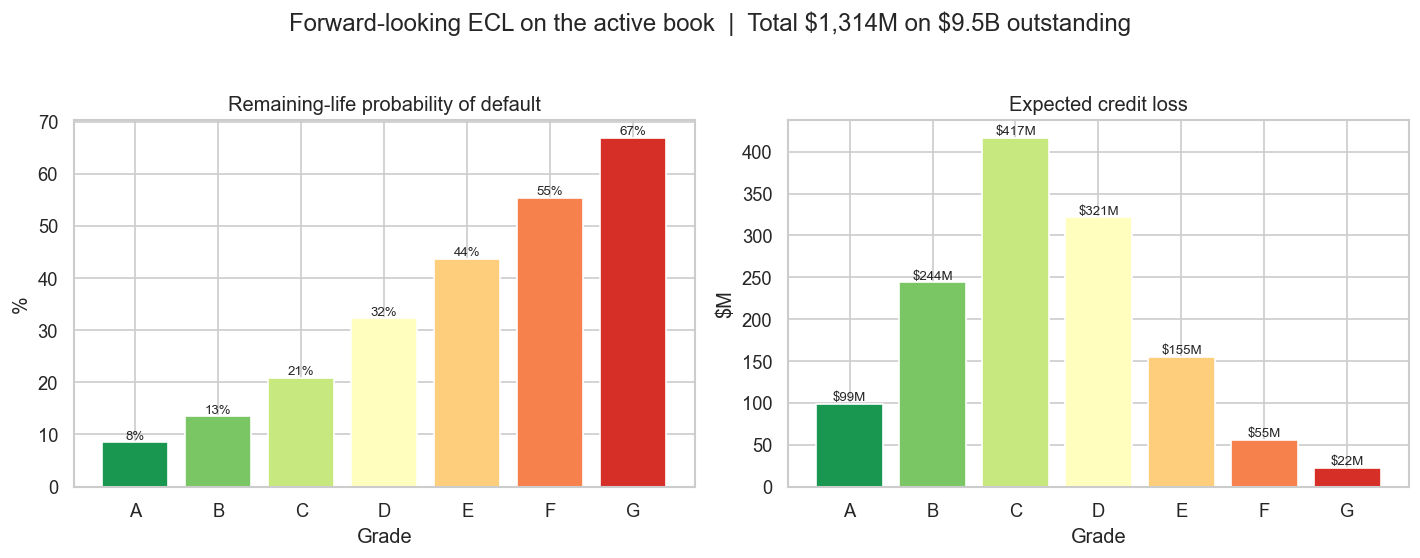

In [5]:
sc = ecl(active, cph)
ecl_total = sc["ecl"].sum()
print(f"Current outstanding: ${exposure/1e9:.2f}B")
print(f"Expected credit loss: ${ecl_total/1e6:,.0f}M  ({ecl_total/exposure:.2%} of outstanding)")
print(f"Avg remaining-life PD {sc['rem_pd'].mean():.1%} | avg exposure-at-default ${sc['ead'].mean():,.0f}")

g = sc.groupby("grade").agg(ecl=("ecl","sum"), pd=("rem_pd","mean"))
print("\nECL by grade ($M):", {k:round(v/1e6) for k,v in g["ecl"].items()})

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
cols = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(g)))
ax[0].bar(g.index, g["pd"]*100, color=cols); ax[0].set_title("Remaining-life probability of default")
ax[0].set_ylabel("%"); ax[0].set_xlabel("Grade")
for i,v in enumerate(g["pd"]*100): ax[0].text(i, v+0.6, f"{v:.0f}%", ha="center", fontsize=8)
ax[1].bar(g.index, g["ecl"]/1e6, color=cols); ax[1].set_title("Expected credit loss")
ax[1].set_ylabel("$M"); ax[1].set_xlabel("Grade")
for i,v in enumerate(g["ecl"]/1e6): ax[1].text(i, v+4, f"${v:.0f}M", ha="center", fontsize=8)
plt.suptitle(f"Forward-looking ECL on the active book  |  Total \${ecl_total/1e6:,.0f}M on \${exposure/1e9:.1f}B outstanding", y=1.03)
plt.tight_layout(); plt.savefig("../output/figures/ecl_by_grade.png", dpi=150, bbox_inches="tight"); plt.show()

## A bad year is *systemic*, not random

With ~900k loans, individual-loan default randomness diversifies away almost
entirely; the reserve's real uncertainty is a downturn lifting everyone's default
rate at once, so we stress by scaling PD.

  Base           $1,314M (13.84% of outstanding)
  Mild +25%      $1,589M (16.74% of outstanding)
  Moderate +50%  $1,852M (19.51% of outstanding)
  Severe x2      $2,338M (24.64% of outstanding)
  Extreme x2.5   $2,768M (29.17% of outstanding)


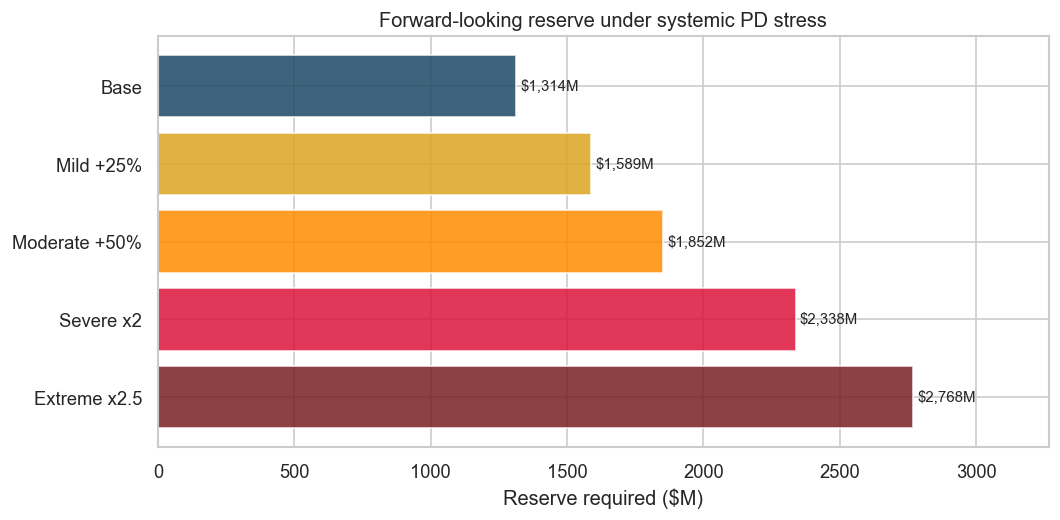

In [6]:
scen = [("Base",1.0),("Mild +25%",1.25),("Moderate +50%",1.5),("Severe x2",2.0),("Extreme x2.5",2.5)]
vals = [float((np.minimum(sc["rem_pd"]*k,1.0)*LGD*sc["ead"]).sum()) for _,k in scen]
for (lab,_),v in zip(scen, vals):
    print(f"  {lab:14s} ${v/1e6:,.0f}M ({v/exposure:.2%} of outstanding)")

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#1b4965","goldenrod","darkorange","crimson","#7a1f24"]
labels = [s for s,_ in scen]
bars = ax.barh(labels[::-1], [v/1e6 for v in vals][::-1], color=colors[::-1], alpha=0.85)
for b,v in zip(bars, vals[::-1]):
    ax.text(b.get_width()+15, b.get_y()+b.get_height()/2, f"${v/1e6:,.0f}M", va="center", fontsize=9)
ax.set_xlabel("Reserve required ($M)"); ax.set_xlim(0, max(vals)/1e6*1.18)
ax.set_title("Forward-looking reserve under systemic PD stress")
plt.tight_layout(); plt.savefig("../output/figures/ecl_stress.png", dpi=150); plt.show()

## Backtest — predicted vs realized loss by vintage

Train on loans issued ≤ 2014, predict each vintage's lifetime loss rate, and compare
to realized loss (principal owed at default, net of recoveries, as a share of funded).
Predicted tracks realized on matured, normal-condition vintages (running slightly
conservative); 2007–08 is under-predicted (no macro variable) and recent vintages
haven't matured.

            predicted  realized
issue_year                     
2007.0            8.1      19.1
2008.0            7.7      14.9
2009.0            7.1       8.8
2010.0            9.4       8.5
2011.0           11.7      10.2
2012.0           12.2      10.2
2013.0           13.0       9.2
2014.0           12.8      10.3
2015.0           12.0      11.2
2016.0           11.8      10.8
2017.0           12.1       7.2
2018.0           11.1       1.7


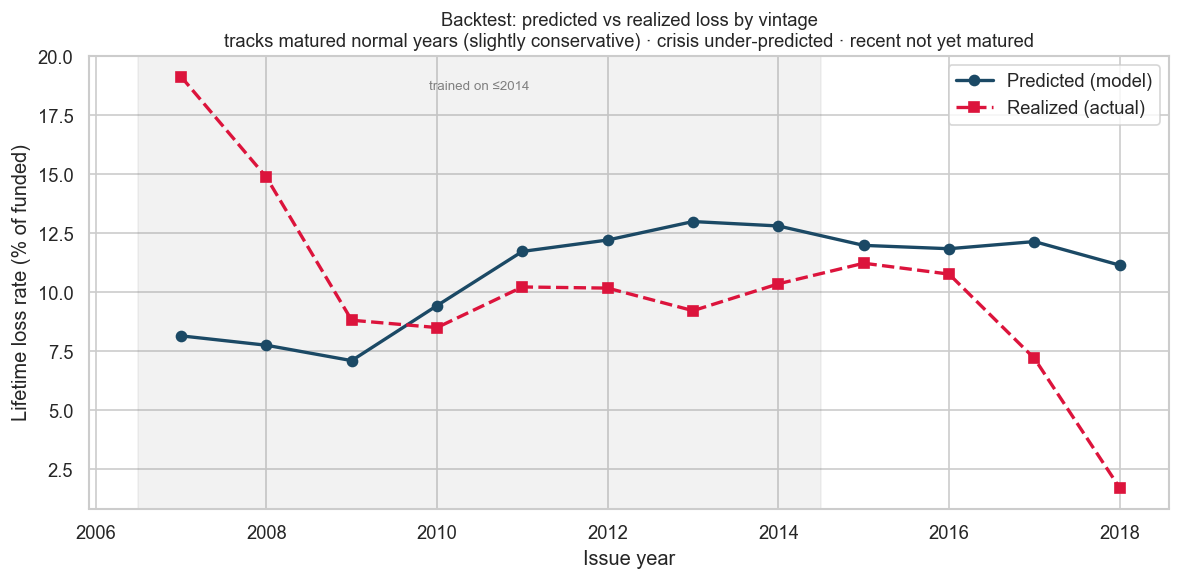

In [7]:
bt = df[df["issue_year"] <= 2014]
cph_bt = fit_survival(bt)
life = df.copy(); life["age0"] = 0.0
life = ecl(life, cph_bt, age_col="age0", use_status=False)
life["realloss"] = np.where(life["loan_status"].isin(CHARGED),
    (life["loan_amnt"]-life["total_rec_prncp"]-life["recoveries"]).clip(lower=0), 0.0)
by = life.groupby("issue_year").apply(lambda d: pd.Series({
        "predicted": d["ecl"].sum()/d["loan_amnt"].sum()*100,
        "realized":  d["realloss"].sum()/d["loan_amnt"].sum()*100}), include_groups=False)
print(by.round(1).to_string())

yrs = by.index.values
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yrs, by["predicted"], "o-", color="#1b4965", lw=2, label="Predicted (model)")
ax.plot(yrs, by["realized"], "s--", color="crimson", lw=2, label="Realized (actual)")
ax.axvspan(yrs.min()-0.5, 2014.5, color="gray", alpha=0.10)
ax.text(2010.5, ax.get_ylim()[1]*0.93, "trained on ≤2014", fontsize=8, color="gray", ha="center")
ax.set_xlabel("Issue year"); ax.set_ylabel("Lifetime loss rate (% of funded)")
ax.set_title("Backtest: predicted vs realized loss by vintage\n"
             "tracks matured normal years (slightly conservative) · crisis under-predicted · recent not yet matured", fontsize=11)
ax.legend()
plt.tight_layout(); plt.savefig("../output/figures/ecl_backtest.png", dpi=150, bbox_inches="tight"); plt.show()

## Values baked into the dashboard

The interactive dashboard is parameterised from the numbers below — the per-grade
ECL at each downturn scenario, the constant LGD, and the recovery rate.

In [8]:
gl = ["A","B","C","D","E","F","G"]
print(f"LGD = {LGD:.3f}  recovery = {1-LGD:.3f}")
print(f"current outstanding ($M): {exposure/1e6:.0f}")
print(f"per-grade outstanding ($M): {[round(active.groupby('grade')['out_prncp'].sum()[g]/1e6) for g in gl]}")
print(f"per-grade remaining PD: {[round(g_['rem_pd'].mean(),4) for _,g_ in sc.groupby('grade')]}")
for lab,k in scen:
    per = [round((np.minimum(sc.loc[sc['grade']==gg,'rem_pd']*k,1.0)*LGD*sc.loc[sc['grade']==gg,'ead']).sum()/1e6) for gg in gl]
    print(f"  {lab:14s} total ${sum(per)}M  per-grade {per}")

LGD = 0.891  recovery = 0.109
current outstanding ($M): 9489


per-grade outstanding ($M): [1999, 2671, 2841, 1364, 454, 120, 40]


per-grade remaining PD: [np.float64(0.0845), np.float64(0.1348), np.float64(0.2086), np.float64(0.3228), np.float64(0.4364), np.float64(0.5534), np.float64(0.6689)]


  Base           total $1313M  per-grade [99, 244, 417, 321, 155, 55, 22]


  Mild +25%      total $1589M  per-grade [121, 295, 503, 389, 188, 67, 26]


  Moderate +50%  total $1852M  per-grade [143, 346, 589, 457, 218, 72, 27]


  Severe x2      total $2338M  per-grade [187, 447, 760, 590, 250, 76, 28]


  Extreme x2.5   total $2767M  per-grade [231, 549, 932, 687, 262, 78, 28]
